In [1]:
import pandas as pd
import numpy as np
import random
import fastparquet
from pandas.tseries.holiday import USFederalHolidayCalendar as uscalendar
import matplotlib.pyplot as plt
import seaborn as sns
uscal = uscalendar()

# importing the models we will test out
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import PolynomialFeatures

# addition predifined 'functions' we need for splitting the data and evaluating the model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 100)

# Problem context.

#### Predict what departure delay is expected for any scheduled fight. What is an error of the model's prediction on the test set? 
#### The data refer to flights from 07.2018 and 06.2019, so we can use the data to predict flight delays in 07.2019 to 08.2019

<ol>
  <li>Regression/multi-classification problem.
</li>
  <li>22 variables per dataset.</li>
  <li>Using only the 8 most common carrier.</li>
  <li>Variable response is 'DEP_DELAY'</li>
</ol>

# Collecting the data

In [2]:
# Due to my laptop's limited resources I had to choose between sampling the data or only using the last 2 months
# I choose the second option because adding previous flights to the analyzed flights 
# would be nearly inpossible with using 10% sample of each month
# I also left the classes 'in space' to make the notebook easier to read

training_csv_list = ['2019_05','2019_06']
for csv in training_csv_list:
    
    df = pd.read_csv(f'DS_data_input/{csv}.csv')
    df.drop(['CANCELLATION_CODE','Unnamed: 22'], axis=1, inplace=True)

    try:
        df_full_train = pd.concat([df_full_train,df])
    except:
        df_full_train = df

# Initial data exploration

In [3]:
#Dataframe summary
pd.DataFrame({'unicos':df_full_train.nunique(),
              'missing': df_full_train.isna().sum()/df_full_train.count(),
              'tipo':df_full_train.dtypes,
              'max': df_full_train.max(),
              'min': df_full_train.min()})

,unicos,missing,tipo,max,min
FL_DATE,61,0.000000,object,2019-06-30,2019-05-01
OP_UNIQUE_CARRIER,17,0.000000,object,YX,9E
OP_CARRIER_FL_NUM,6583,0.000000,int64,7439,1
ORIGIN,358,0.000000,object,YUM,ABE
DEST,358,0.000000,object,YUM,ABE
CRS_DEP_TIME,1253,0.000000,int64,2359,4
DEP_TIME,1438,0.020134,float64,2400.0,1.0
DEP_DELAY,1223,0.020138,float64,2058.0,-82.0
CRS_ARR_TIME,1331,0.000000,int64,2359,1
ARR_TIME,1440,0.021407,float64,2400.0,1.0


# -------------------- Data Preparation ---------------------

In [4]:
class data_preparation():
    
    def __init__(self,df,carrier_list):
        self.df = df
        self.carrier_list = carrier_list
        self.data_filteration()
        self.data_type_manipulation()
        self.create_arrival_table()
        self.create_departure_table()
        print('Data Preparation is done')

    #filtering the data for selected carriers and non 'nan' delay values
    #we delete useless columns and filter out the unnesessary carries and rows without deparment delay and arrive delay
    def data_filteration(self):

        #filter out rows with 'nan' values
        self.df = self.df[self.df["DEP_DELAY"].notnull()]
        self.df = self.df[self.df["ARR_DELAY"].notnull()]
        self.df = self.df[self.df['OP_UNIQUE_CARRIER'].isin(self.carrier_list)]

    #filling 'nan' values for delay kinds
    #we reassing smaller/more compact datatypes to each column to reduct the dataset's memory consumption
    def data_type_manipulation(self):

        self.df = self.df.fillna({'CARRIER_DELAY' : 0,
                                'WEATHER_DELAY' : 0,
                                'NAS_DELAY' : 0,
                                'SECURITY_DELAY' :0,
                                'LATE_AIRCRAFT_DELAY' : 0})

        self.df['FL_DATE'] = pd.to_datetime(self.df['FL_DATE'])
        self.df['OP_UNIQUE_CARRIER'] = self.df['OP_UNIQUE_CARRIER'].astype('category')

        int_columns = ['OP_CARRIER_FL_NUM','CRS_DEP_TIME','DEP_TIME','DEP_DELAY','CRS_ARR_TIME',
                       'ARR_TIME','CRS_ELAPSED_TIME','ACTUAL_ELAPSED_TIME','AIR_TIME','DISTANCE','ARR_DELAY',
                       'CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY','SECURITY_DELAY','LATE_AIRCRAFT_DELAY','CANCELLED']

        for col in int_columns:
            self.df[col] = self.df[col].astype('int16')
    
    def create_arrival_table(self):
        
        arrival_table = self.df
        supp_cols = ['FL_DATE','OP_UNIQUE_CARRIER','OP_CARRIER_FL_NUM', 'DEST','ARR_TIME',
                 'ARR_DELAY','ACTUAL_ELAPSED_TIME','AIR_TIME','DISTANCE','CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY',
                 'SECURITY_DELAY','LATE_AIRCRAFT_DELAY','CRS_ARR_DATETIME']

        arrival_supp_cols = ['arrival_' + s for s in supp_cols]
        
        arrival_table = self.df
        
        arrival_table['CRS_ARR_TIME'] = arrival_table['CRS_ARR_TIME'].astype(str).str.zfill(4)
        arrival_table['CRS_ARR_HOUR'] = arrival_table['CRS_ARR_TIME'].astype(str).str[0:2].str.zfill(2)
        arrival_table['CRS_ARR_MIN'] = arrival_table['CRS_ARR_TIME'].astype(str).str[2:4].str.zfill(2)
        arrival_table['CRS_ARR_DATETIME'] = pd.to_datetime(arrival_table['FL_DATE'].astype(str) + ' ' +\
                                                    arrival_table['CRS_ARR_HOUR'] + ':'+\
                                                    arrival_table['CRS_ARR_MIN'] + ':00',
                                                    format="%Y-%m-%d %H:%M:%S")


        arrival_table = arrival_table[supp_cols]
        arrival_table.columns = arrival_supp_cols

        arrival_table['arrival_CRS_ARR_DATETIME_plus3hours'] = arrival_table['arrival_CRS_ARR_DATETIME'] +\
                                                               pd.DateOffset(hours=3)

        arrival_table['uniqueID'] = arrival_table['arrival_OP_UNIQUE_CARRIER'].astype(str) +\
                                    arrival_table['arrival_OP_CARRIER_FL_NUM'].astype(str) +\
                                    arrival_table['arrival_DEST'].astype(str)

        arrival_table.to_csv('DS_intermediate_data/flight_arrival_data.csv', index = False)
    
    
    def create_departure_table(self):
        
        departure_table = self.df
        supp_cols = ['FL_DATE','OP_UNIQUE_CARRIER','OP_CARRIER_FL_NUM', 'ORIGIN','DEST','CRS_DEP_TIME','DEP_DELAY',
                     'DISTANCE','CRS_DEP_HOUR','CRS_DEP_DATETIME']

        departure_supp_cols = ['departure_' + s for s in supp_cols]

        departure_table['CRS_DEP_TIME'] = departure_table['CRS_DEP_TIME'].astype(str).str.zfill(4)
        departure_table['CRS_DEP_HOUR'] = departure_table['CRS_DEP_TIME'].astype(str).str[0:2].str.zfill(2)
        departure_table['CRS_DEP_MIN'] = departure_table['CRS_DEP_TIME'].astype(str).str[2:4].str.zfill(2)
        departure_table['CRS_DEP_DATETIME'] = pd.to_datetime(departure_table['FL_DATE'].astype(str) + ' ' +\
                                                 departure_table['CRS_DEP_HOUR'] + ':'+\
                                                 departure_table['CRS_DEP_MIN'] + ':00',
                                                 format="%Y-%m-%d %H:%M:%S")

        departure_table = departure_table[supp_cols]
        departure_table.columns = departure_supp_cols

        departure_table['uniqueID'] = departure_table['departure_OP_UNIQUE_CARRIER'].astype(str) +\
                                      departure_table['departure_OP_CARRIER_FL_NUM'].astype(str) +\
                                      departure_table['departure_ORIGIN'].astype(str)

        departure_table.to_parquet('DS_intermediate_data/flight_departure_data.parquet')

In [5]:
# the 8 most common carrier based on the test datasets are the followings:
carrier_list = ['WN','DL','AA','OO','UA','MQ','YX','B6']
data_preparation(df_full_train,carrier_list)

Data Preparation is done


# --------- Data Engineering ------------------

In [6]:
class data_engineering():
    
    def __init__(self,dep,arr, kind):
        self.dep = dep
        self.arr = arr
        self.kind = kind
        self.load_arrival_pairs()
        self.dep_w_arr = pd.read_csv('DS_intermediate_data/dep_and_arr.csv')
        self.adding_arrival_fights()
    
    
    def load_arrival_pairs(self, arr_name = 'flight_arrival_data', dep_w_arr_name = 'dep_and_arr'):

        # creating a empty bucket to save result
        df_result = pd.DataFrame(columns=(self.dep.columns.append(self.arr.columns)).unique())
        df_result.to_csv(f"DS_intermediate_data/{dep_w_arr_name}.csv",index_label=False)

        def preprocess(x):
            df2=pd.merge(self.dep,x, left_on = "uniqueID", right_on = "uniqueID")\
                  .query('departure_CRS_DEP_DATETIME.between(`arrival_CRS_ARR_DATETIME`, `arrival_CRS_ARR_DATETIME_plus3hours`)')

            df2.to_csv(f"DS_intermediate_data/{dep_w_arr_name}.csv",mode="a",header=False,index=False)

        reader = pd.read_csv(f'DS_intermediate_data/{arr_name}.csv', chunksize=10000) # chunksize 

        #do not show output
        [preprocess(r) for r in reader];
        
    def adding_arrival_fights(self, dep_plus_name ='flight_departure_plus_data'):

        self.dep_w_arr["arr_dep_time_diff"] =  (pd.to_datetime(self.dep_w_arr['departure_CRS_DEP_DATETIME']) - 
                                               pd.to_datetime(self.dep_w_arr['arrival_CRS_ARR_DATETIME'])).astype('timedelta64[m]')

        self.dep_w_arr['departure_FL_DATE'] = pd.to_datetime(self.dep_w_arr['departure_FL_DATE'])
        self.dep_w_arr['arrival_CRS_ARR_DATETIME'] = pd.to_datetime(self.dep_w_arr['arrival_CRS_ARR_DATETIME'])


        int_columns = ['departure_CRS_DEP_TIME',
                       'arrival_ARR_TIME','arrival_ARR_DELAY','arrival_ACTUAL_ELAPSED_TIME', 'arrival_AIR_TIME',
                       'arrival_DISTANCE', 'arrival_CARRIER_DELAY', 'arrival_WEATHER_DELAY',
                       'arrival_NAS_DELAY', 'arrival_SECURITY_DELAY',
                       'arrival_LATE_AIRCRAFT_DELAY','arr_dep_time_diff']


        for col in int_columns:
            self.dep_w_arr[col] = self.dep_w_arr[col].astype('int16')

        dep_w_arr_cols = ['uniqueID','departure_FL_DATE','arrival_CRS_ARR_DATETIME'] + int_columns
        self.dep_w_arr = self.dep_w_arr[dep_w_arr_cols]

        self.dep['departure_CRS_DEP_TIME'] = self.dep['departure_CRS_DEP_TIME'].astype('int16')
        self.dep_plus = pd.merge(self.dep,self.dep_w_arr, on = ['uniqueID','departure_FL_DATE','departure_CRS_DEP_TIME'],
                                       how = 'left')
        self.dep_plus = self.dep_plus.fillna(0)
        dep_plus_int_columns = ['arrival_ARR_TIME', 'arrival_ARR_DELAY',
                                'arrival_ACTUAL_ELAPSED_TIME', 'arrival_AIR_TIME', 'arrival_DISTANCE',
                                'arrival_CARRIER_DELAY', 'arrival_WEATHER_DELAY', 'arrival_NAS_DELAY',
                                'arrival_SECURITY_DELAY', 'arrival_LATE_AIRCRAFT_DELAY',
                                'arr_dep_time_diff']


        for col in dep_plus_int_columns:
            self.dep_plus[col] = self.dep_plus[col].astype('int16')

        self.dep_plus['arrival_CRS_ARR_DATETIME'] = self.dep_plus['arrival_CRS_ARR_DATETIME'].astype(str)
        del self.dep_plus['uniqueID']
        self.dep_plus.to_parquet(f'DS_intermediate_data/{dep_plus_name}_{self.kind}.parquet')

In [7]:
dep = pd.read_parquet('DS_intermediate_data/flight_departure_data.parquet', engine='fastparquet')
arr = pd.read_csv('DS_intermediate_data/flight_arrival_data.csv')

data_engineering(dep, arr, kind = 'train')

# ----------------------- Feature Engineering ----------

In [2]:
class feature_engineering():

    def __init__(self,df,uscal):
        self.df = df
        self.uscal = uscal
        self.feature_enginering()
        self.data_discretization()
        self.top_airport_categorization()
        self.adding_mean_values()
        
    def feature_enginering(self):
        #create arrival-departure time difference if null = 120
        self.df['arr_dep_time_diff'] = np.where(self.df['arr_dep_time_diff'] == 0, 120, self.df['arr_dep_time_diff'])
        #create departure time based categorical feature
        self.df['departure_CRS_DEP_HOUR'] = self.df['departure_CRS_DEP_HOUR']+'H'
        #adding weekday column
        self.df["weekday_num"] = self.df["departure_FL_DATE"].dt.day_name().astype('category')
        #adding bool US holiday column
        #cal = uscalendar()
        holidays = self.uscal.holidays(start=self.df.departure_FL_DATE.min(), end=self.df.departure_FL_DATE.max())
        self.df['holiday'] = self.df['departure_FL_DATE'].isin(holidays).astype('int16')
        
    def data_discretization(self):

        #bucketing based on departure flight distance
        dist_bins = [0, 
                dep_plus['departure_DISTANCE'].quantile(0.1),
                dep_plus['departure_DISTANCE'].quantile(0.3), 
                dep_plus['departure_DISTANCE'].quantile(0.6),
                dep_plus['departure_DISTANCE'].quantile(0.9),
                dep_plus['departure_DISTANCE'].quantile(1)]

        dist_labels = ['dep_very_short_dist',
                  'dep_short_dist',
                  'dep_avg_dist',
                  'dep_long_dist',
                  'dep_very_long_dist']

        self.df['departure_distance_bin'] = pd.cut(self.df['departure_DISTANCE'],
                                                bins=dist_bins,
                                                labels=dist_labels).astype('category')

        #bucketing based on arrival flight distance
        arr_dist_labels = ['arr_very_short_dist',
                  'arr_short_dist',
                  'arr_avg_dist',
                  'arr_long_dist',
                  'arr_very_long_dist']

        self.df['arrival_distance_bin'] = pd.cut(self.df['arrival_DISTANCE'],
                                                    bins=dist_bins,
                                                    labels=arr_dist_labels)

        self.df['arrival_distance_bin'] = np.where (self.df['arrival_distance_bin'].isnull(),'arr_unknown_dist',
                                               self.df['arrival_distance_bin'])

        self.df['arrival_distance_bin'] = self.df['arrival_distance_bin'].astype('category')
        
    def top_airport_categorization(self):
        #create departure origins buckets
        top50_airports = self.df.departure_ORIGIN.value_counts().index[:50].tolist()

        self.df['departure_ORIGIN'] = np.where (self.df['departure_ORIGIN'].isin(top50_airports),
                                                self.df['departure_ORIGIN'],
                                                 'other_airport')
        self.df['departure_ORIGIN'] = self.df['departure_ORIGIN'].astype('category')
        
    def adding_mean_values(self):
        
        #creating departure time in minutes
        self.df['dep_time'] = self.df['departure_CRS_DEP_DATETIME'].dt.time
        self.df['dep_time_min'] = self.df['dep_time'].apply(lambda x:x.hour*60+x.minute)
        #creating departure time in minutes
        self.df['arr_time'] =  pd.to_datetime(self.df['arrival_CRS_ARR_DATETIME'],format='%Y-%m-%d', errors='coerce').dt.time
        self.df['arr_time_min'] = self.df['arr_time'].apply(lambda x:x.hour*60+x.minute)
        self.df = self.df.fillna({'arr_time' : 0,
                                'arr_time_min' : 0})
        
        #creating departure level mean metrics
        df_mean = pd.DataFrame(self.df['departure_DEP_DELAY'].groupby(self.df['dep_time']).mean()).astype('int16')
        df_mean.rename({'departure_DEP_DELAY': 'dep_time_based_expected_delay'}, axis=1, inplace=True)
        self.df = pd.merge(self.df,df_mean, on = 'dep_time')
        #creating origin level mean metrics
        df_origin_mean = pd.DataFrame(self.df['departure_DEP_DELAY'].groupby(self.df['departure_ORIGIN']).mean()).astype('int16')
        df_origin_mean.rename({'departure_DEP_DELAY': 'origin_based_expected_delay'}, axis=1, inplace=True)
        self.df = pd.merge(self.df,df_origin_mean, on = 'departure_ORIGIN')
        #creating airline level mean metrics
        df_airline_mean = pd.DataFrame(self.df['departure_DEP_DELAY'].groupby(self.df['departure_OP_UNIQUE_CARRIER']).mean()).astype('int16')
        df_airline_mean.rename({'departure_DEP_DELAY': 'airline_based_expected_delay'}, axis=1, inplace=True)
        self.df = pd.merge(self.df,df_airline_mean, on = 'departure_OP_UNIQUE_CARRIER')
            
    def give_dataframe(self):
        
        return self.df

In [3]:
#read parquet
dep_plus = pd.read_parquet('DS_intermediate_data/flight_departure_plus_data_train.parquet', engine='fastparquet')

feature_engineering = feature_engineering(dep_plus,uscal)
dep_plus = feature_engineering.give_dataframe()

# ----------- Exploratory Data Analysis ---------

In [10]:
print ('Good day Sir')
print ('The script is running')
print ("total rows of data:", len(dep_plus))
print ("total rows of fligh small delays:", len(dep_plus[dep_plus['departure_DEP_DELAY'] > 0]))
print ("total rows of fligh big delays:", len(dep_plus[dep_plus['departure_DEP_DELAY'] > 15]))
print ("total rows of fligh hour+ delays:", len(dep_plus[dep_plus['departure_DEP_DELAY'] > 60]))
print (dep_plus['departure_OP_UNIQUE_CARRIER'].value_counts())

Good day Sir
The script is running
total rows of data: 959167
total rows of fligh small delays: 383625
total rows of fligh big delays: 206794
total rows of fligh hour+ delays: 77528
WN    225804
DL    172202
AA    154716
OO    141501
UA    107168
MQ     54699
YX     54207
B6     48870
Name: departure_OP_UNIQUE_CARRIER, dtype: int64


## Lets analys the correlation between the features

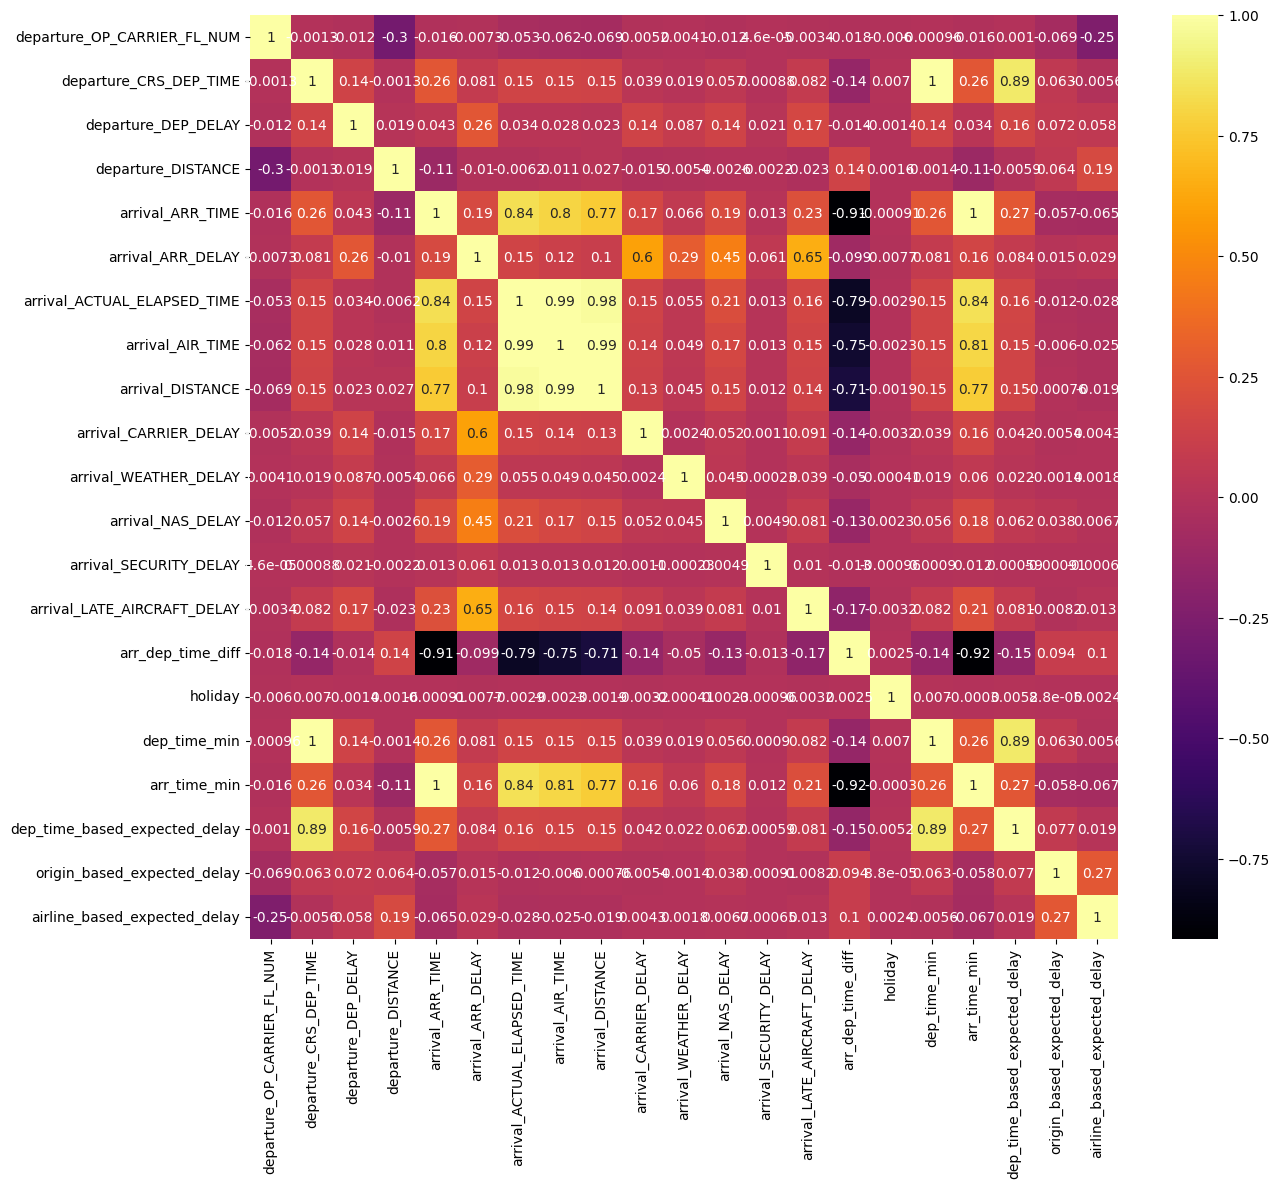

In [11]:
# Dataframe correlation
del_corr = dep_plus.corr()

# Draw the figure
f, ax = plt.subplots(figsize=(14, 12))

# Draw the heatmap
sns.heatmap(del_corr,annot=True,cmap='inferno')
plt.show()

#### Among other things we can see that the delay of the previous flight of the same airplane and the scheduled departure time have the biggest impact on the departure delay of any flight

### How a standard departure delay looks like? 

Median -1.0 -- true average departure delay
Mean 14.128199781685566 -- mean is skewed by huge inexpected delays
Mode -3 -- most likely departure delay


<AxesSubplot: >

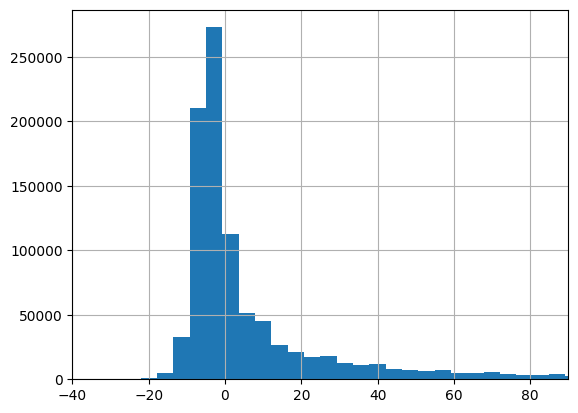

In [12]:
print ("Median", dep_plus["departure_DEP_DELAY"].median(), "-- true average departure delay")
print ("Mean", dep_plus["departure_DEP_DELAY"].mean(), "-- mean is skewed by huge inexpected delays")
print ("Mode", dep_plus["departure_DEP_DELAY"].mode()[0], "-- most likely departure delay")

plt.xlim(xmin=-40, xmax = 90)
dep_plus['departure_DEP_DELAY'].hist(bins = 500)

## How airplane arrival effects departure delays?

In [13]:
dep_plus_w_pre = dep_plus[dep_plus['arrival_ARR_TIME'] > 0]
dep_plus_w_pre['arrive_isontime'] = np.where(dep_plus_w_pre['arrival_ARR_DELAY'] <= 0,'ontime','notontime')

arrive_effect = pd.DataFrame(dep_plus_w_pre.groupby('arrive_isontime')\
                    ['departure_DEP_DELAY'].mean())

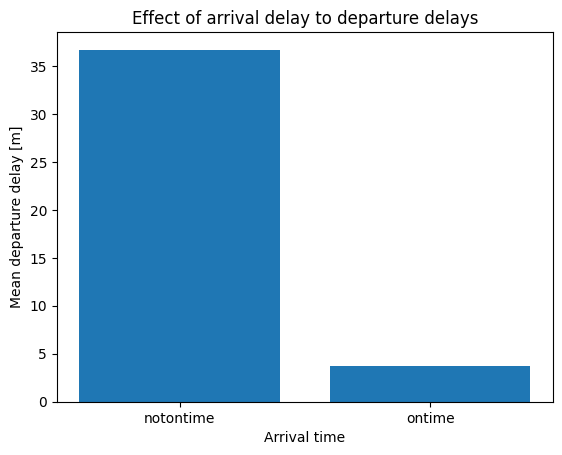

In [14]:
plt.bar(arrive_effect.index, arrive_effect['departure_DEP_DELAY'])
plt.title('Effect of arrival delay to departure delays')
plt.xlabel('Arrival time')
plt.ylabel('Mean departure delay [m]')
plt.show()

#### As we expected if the previous flight arrived late the chances are high that the later flight will depart later than expected/scheduled.

## How departure weekday influence departure delays?

In [15]:
dayofweek_effect = pd.DataFrame(dep_plus.groupby('weekday_num')\
                                ['departure_DEP_DELAY'].mean())

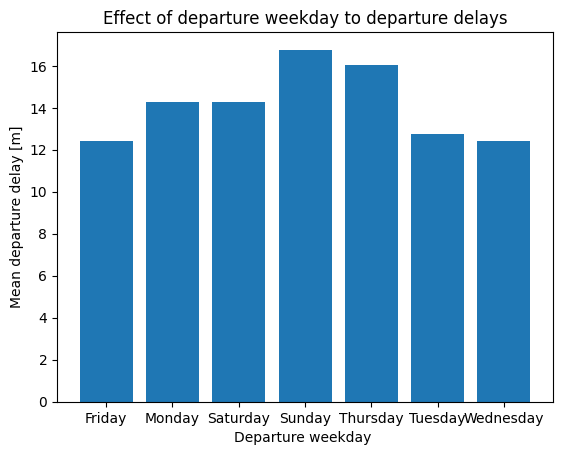

In [16]:
plt.bar(dayofweek_effect.index, dayofweek_effect['departure_DEP_DELAY'])
plt.title('Effect of departure weekday to departure delays')
plt.xlabel('Departure weekday ')
plt.ylabel('Mean departure delay [m]')
plt.show()

#### We can see from the picture that the average departure delay on Sunday is more than 30% more than on Wednesday when the average delay is the smallest.

## How much influence the Airline has on departure delays?

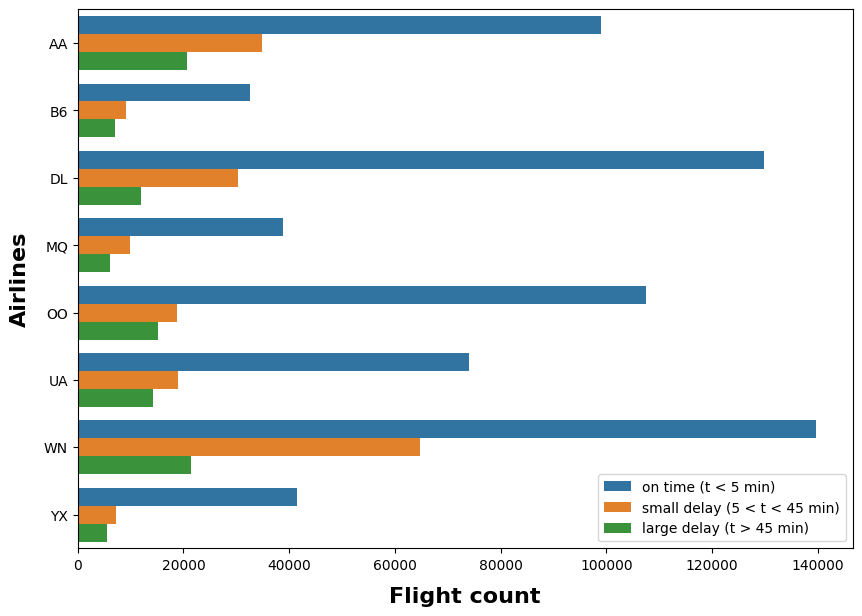

In [17]:
# Function that define how delays are grouped
delay_type = lambda x:((0,1)[x > 5],2)[x > 45]
dep_plus['DELAY_LEVEL'] = dep_plus['departure_DEP_DELAY'].apply(delay_type)

fig = plt.figure(1, figsize=(10,7))
ax = sns.countplot(y="departure_OP_UNIQUE_CARRIER", hue='DELAY_LEVEL', data=dep_plus)
# set the labels
plt.ylabel('Airlines',fontsize=16, weight = 'bold', labelpad=10)
plt.xlabel('Flight count', fontsize=16, weight = 'bold', labelpad=10)

# Set the legend
L = plt.legend()
L.get_texts()[0].set_text('on time (t < 5 min)')
L.get_texts()[1].set_text('small delay (5 < t < 45 min)')
L.get_texts()[2].set_text('large delay (t > 45 min)')
plt.show()
del dep_plus['DELAY_LEVEL']

#### This figure gives a count of the delays of less than 5 minutes, those in the range 5 < t < 45 min, and finally, the delays greater than 45 minutes. 
#### We can see that independently of the airline, delays greater than 45 minutes are rare and only account for a few percent. However, the proportion of delays in these three groups depends largely on the airlines.

## Is the mean department delay is significantly different for the carrier types?

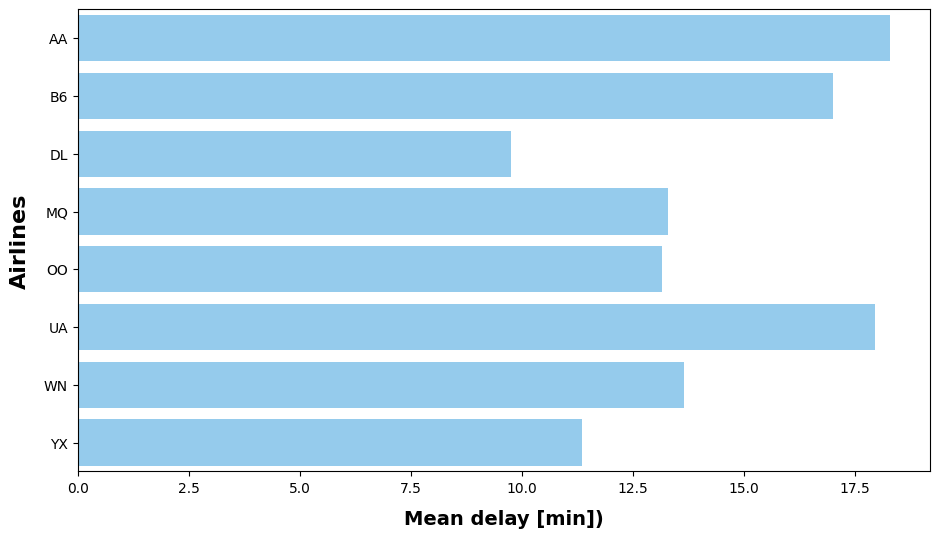

In [18]:
fig = plt.figure(1, figsize=(11,6))

ax = sns.barplot(x="departure_DEP_DELAY",
                 y="departure_OP_UNIQUE_CARRIER",
                 data=dep_plus,
                 color="lightskyblue",
                 ci=None)

plt.ylabel('Airlines',fontsize=16, weight = 'bold', labelpad=10)
plt.xlabel('Mean delay [min])',\
           fontsize=14, weight = 'bold', labelpad=10)
plt.show()

#### From the above graph, we can safely say that the expectancy of delay largely depends on the airlines. Out of the eight most common airlines, 'AA' airline has the highest mean delay, almost 18 minutes, while 'DL' airline's mean delay is less than 10 minutes. The difference is significant!

## What is the relation between the origin airport and delays?

In [19]:
print("Number of airports: {}".format(len(dep_plus['departure_ORIGIN'].unique())))

airport_mean_delays1 = pd.DataFrame(dep_plus.groupby(['departure_ORIGIN','departure_OP_UNIQUE_CARRIER'])\
                    ['departure_DEP_DELAY'].mean())

airport_mean_delays2 = pd.pivot_table(airport_mean_delays1, values = 'departure_DEP_DELAY',
                      index=['departure_ORIGIN'],
                      columns = 'departure_OP_UNIQUE_CARRIER')

Number of airports: 51


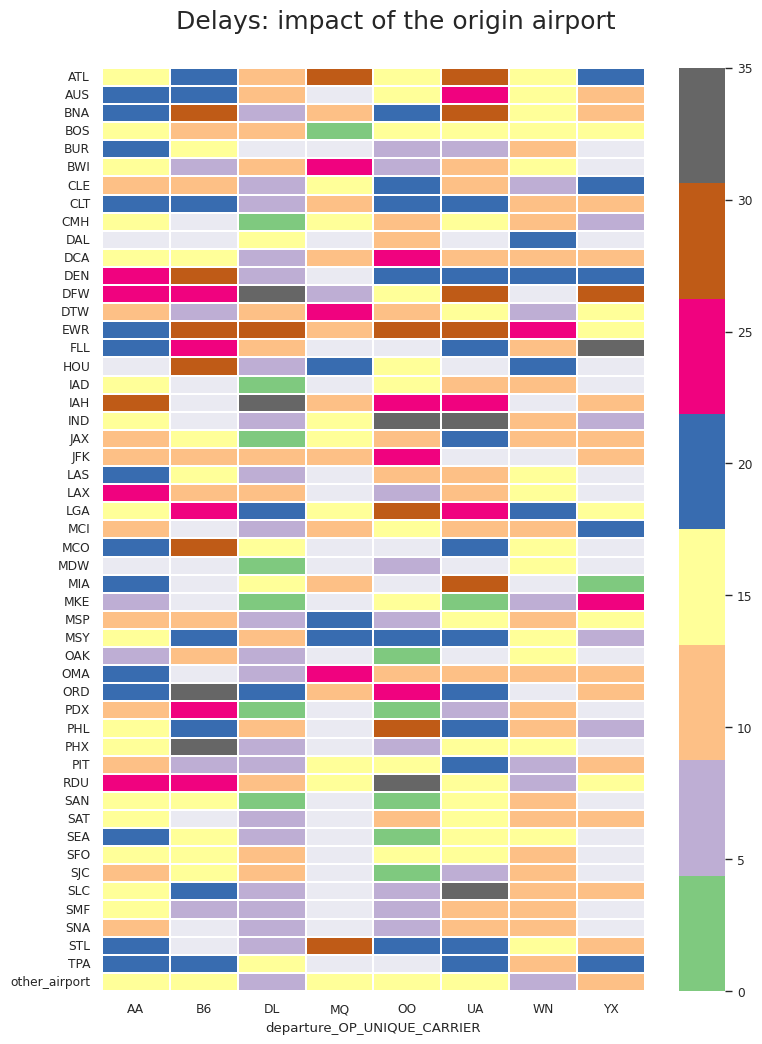

In [20]:
sns.set(context="paper")
fig = plt.figure(1, figsize=(8,10))
fig.text(0.5, 1.02, "Delays: impact of the origin airport", ha='center', fontsize = 18)

ax = fig.add_subplot(1,1,1)
subset = airport_mean_delays2.iloc[:51,:]
mask = subset.isnull()
sns.heatmap(subset, linewidths=0.02, cmap="Accent", mask=mask, vmin = 0, vmax = 35)
ax.yaxis.label.set_visible(False)

plt.tight_layout()
plt.show()

#### This figure allows drawing some conclusions. First, by looking at the data of different airlines, we find the behavior we previously recognized.  Thus we can see that the columns associated with 'B6' and 'OO' mostly report large delays, while the column associated with 'DL' and ''WN' is mainly associated with delays of less than 5 minutes. If we now look at the airports of origin, we will see that some airports favor late departures, such as 'IND', 'DFW', 'IAH'. Conversely, other airports will mainly know on-time departures such as 'BOS' or 'SAN'.

#### Finally, we can assume from these observations that there is high variability in average delays, both between the different airports and also between the different airlines. This is important because it implies that to accurately model the delays, it will be necessary to adopt a model that is specific to the company and the departure origin.

# ------------------- Predicting flight delays ------------

# Model preparation

In [4]:
class model_support_functions():
    
    def categorical_to_numerical_convert(self,df,cat_columns):

        for column in cat_columns:
            one_hot = pd.get_dummies(df[column])
            # Drop column as it is now encoded
            df = df.drop(column,axis = 1)
            # Join the encoded df
            df = df.join(one_hot)

        return df

    def IQR_outlier_treatment(self,df, datacolumn, V1 , V3):

        Q1,Q3 = np.percentile(df[datacolumn] , [V1,V3])
        IQR = Q3 - Q1
        lower_range = Q1 - (1.5 * IQR)
        upper_range = Q3 + (1.5 * IQR)

        #print(f'{datacolumn} minimum range:',lower_range)
        #print(f'{datacolumn} maximum range:',upper_range) 
        df = df[(df[datacolumn] > lower_range) & (df[datacolumn] < upper_range)]

        return df

    def get_top_correlation(self,df):
        cor = df.corr().abs()
        cor2 = cor.unstack()
        cor3 = cor2.sort_values(kind="quicksort", ascending = False)

        return pd.DataFrame(cor3)

    def evaluate_prediction(self,y_prediction,y_val):

        df_pred = pd.DataFrame({'pred': y_prediction, 'actual': y_val}, columns=['pred', 'actual'])
        df_pred['diff'] = abs(df_pred['actual'] - df_pred['pred'])
        mse = mean_squared_error(df_pred.pred, df_pred.actual)
        rx = r2_score(y_prediction, y_val)

        print('model mean squared error:',mse)
        print('model R2:',rx)
        print('0 diff:',len(df_pred[df_pred['diff'] == 0])/len(df_pred))
        print('1 diff:',len(df_pred[df_pred['diff'] <= 1])/len(df_pred))
        print('5 diff:',len(df_pred[df_pred['diff'] <= 5])/len(df_pred))

        return df_pred


    def try_models(self,model_type,X_train,y_train,X_val,y_val):
        model = model_type
        model.fit(X_train, y_train)
        print('='*20)
        print(f'{model_type}')
        print(f'accuracy of train set: {model.score(X_train, y_train)}')
        print(f'accuracy of val set: {model.score(X_val, y_val)}')

        y_prediction = model.predict(X_val).round(0).astype(int)
        self.evaluate_prediction(y_prediction,y_val)

    # function that extract statistical parameters from a grouby objet:
    def get_mean(self,group):
        return {'mean': group.mean()}

    def get_origin_data(self,df):

        airport_list = ['ATL', 'AUS', 'BNA', 'BOS', 'BUR', 'BWI', 'CLE', 'CLT', 'CMH', 'DAL', 'DCA', 'DEN', 'DFW', 'DTW',
                   'EWR', 'FLL', 'HOU', 'IAD', 'IAH', 'IND', 'JAX', 'JFK', 'LAS', 'LAX',
                   'LGA', 'MCI', 'MCO', 'MDW', 'MIA', 'MKE', 'MSP', 'MSY', 'OAK', 'OMA',
                   'ORD', 'PDX', 'PHL', 'PHX', 'PIT', 'RDU', 'SAN', 'SAT', 'SEA', 'SFO',
                   'SJC', 'SLC', 'SMF', 'SNA', 'STL', 'TPA', 'other_airport']

        try: 
            del airport_data
        except:
            pass

        for airport in airport_list:

            if len(df[df[airport] == 1]) > 0:

                df_airport = df[df[airport] == 1]
                test2 = df_airport['departure_DEP_DELAY'].groupby(df_airport['dep_time_min']).apply(self.get_mean).unstack()
                test2.reset_index(inplace=True)
                test = test2[['mean', 'dep_time_min']].dropna(how='any', axis = 0)
                test['airport'] = airport

                try:
                    airport_data = pd.concat([airport_data, test], ignore_index = True)
                except:
                    airport_data = test.copy()
            else:
                pass

        return airport_data

In [5]:
model_function = model_support_functions()

In [6]:
corr_table = model_function.get_top_correlation(dep_plus)

In [7]:
# get highest correlations to departure_DEP_DELAY
corr_table[corr_table.index.get_level_values(1) == 'departure_DEP_DELAY'][:12]

,,0
departure_DEP_DELAY,departure_DEP_DELAY,1.000000
arrival_ARR_DELAY,departure_DEP_DELAY,0.261595
arrival_LATE_AIRCRAFT_DELAY,departure_DEP_DELAY,0.170850
dep_time_based_expected_delay,departure_DEP_DELAY,0.156823
arrival_CARRIER_DELAY,departure_DEP_DELAY,0.139590
departure_CRS_DEP_TIME,departure_DEP_DELAY,0.139332
dep_time_min,departure_DEP_DELAY,0.139291
arrival_NAS_DELAY,departure_DEP_DELAY,0.139219
arrival_WEATHER_DELAY,departure_DEP_DELAY,0.087345
origin_based_expected_delay,departure_DEP_DELAY,0.072145


In [8]:
selected_features = ['departure_DEP_DELAY','dep_time_min','departure_OP_UNIQUE_CARRIER','departure_ORIGIN',
                     'arrival_ARR_DELAY','arrival_LATE_AIRCRAFT_DELAY','dep_time_based_expected_delay',
                     'arrival_CARRIER_DELAY','arrival_NAS_DELAY','arrival_WEATHER_DELAY','origin_based_expected_delay',
                     'airline_based_expected_delay']

In [9]:
#select only the top features to faster computation
df_model = dep_plus[selected_features]

# convert categorical features to binary columns
cat_columns = ['departure_OP_UNIQUE_CARRIER','departure_ORIGIN']
df_model = model_function.categorical_to_numerical_convert(df_model,cat_columns)

In [10]:
# filter out outlier delays as it would possible damage the model
df_model = model_function.IQR_outlier_treatment(df_model, 'departure_DEP_DELAY',20,80)
df_model = model_function.IQR_outlier_treatment(df_model, 'arrival_ARR_DELAY',5,95)

### Sampling = Reducing the data amount if needed 

In [17]:
df_lenght = int(len(df_model)/2)
df_model = df_model.sample(n = df_lenght)

# Modelling

In [18]:
#selectiong train features(X_train) and traing targets(y_train)
train_feature = ['dep_time_min', 'arrival_ARR_DELAY',
                'arrival_LATE_AIRCRAFT_DELAY', 'dep_time_based_expected_delay',
                'arrival_CARRIER_DELAY', 'arrival_NAS_DELAY', 'arrival_WEATHER_DELAY',
                'origin_based_expected_delay', 'airline_based_expected_delay', 'AA',
                'B6', 'DL', 'MQ', 'OO', 'UA', 'WN', 'YX', 'ATL', 'AUS', 'BNA', 'BOS',
                'BUR', 'BWI', 'CLE', 'CLT', 'CMH', 'DAL', 'DCA', 'DEN', 'DFW', 'DTW',
                'EWR', 'FLL', 'HOU', 'IAD', 'IAH', 'IND', 'JAX', 'JFK', 'LAS', 'LAX',
                'LGA', 'MCI', 'MCO', 'MDW', 'MIA', 'MKE', 'MSP', 'MSY', 'OAK', 'OMA',
                'ORD', 'PDX', 'PHL', 'PHX', 'PIT', 'RDU', 'SAN', 'SAT', 'SEA', 'SFO',
                'SJC', 'SLC', 'SMF', 'SNA', 'STL', 'TPA', 'other_airport']

train_target = 'departure_DEP_DELAY'

In [19]:
#separating X_train and y_train datasets
df_model.reset_index(inplace = True, drop = True)
train_df = df_model[train_feature].astype('int16')
target_df = df_model[train_target].astype('int16')

#splitting the dataframes into train and val datasets
X_train, X_val, y_train, y_val = train_test_split(train_df, target_df, test_size=0.2, random_state=0)

### Try different regression and classification models

In [20]:
models = [LinearRegression(),RidgeClassifier(),LogisticRegression(),
          RandomForestRegressor(),DecisionTreeRegressor(),
          DecisionTreeClassifier(),BernoulliNB()]

In [15]:
# create smaller datasets to make the runtime shorter
X_train_small = X_train[:50000]
y_train_small = y_train[:50000]

X_val_small = X_val[:15000]
y_val_small = y_val[:15000]

In [16]:
print('start model trial')
for modelx in models:

    model_function.try_models(modelx,X_train_small,y_train_small,
                      X_val_small,y_val_small)

start model trial
LinearRegression()
accuracy of train set: 0.1656554917999884
accuracy of val set: 0.16486978461867174
model mean squared error: 126.16326666666667
model R2: -4.134070169222802
0 diff: 0.045733333333333334
1 diff: 0.13446666666666668
5 diff: 0.4968
RidgeClassifier()
accuracy of train set: 0.10084
accuracy of val set: 0.09146666666666667
model mean squared error: 169.61366666666666
model R2: -9.925215390077884
0 diff: 0.09146666666666667
1 diff: 0.26006666666666667
5 diff: 0.6684666666666667
LogisticRegression()
accuracy of train set: 0.08488
accuracy of val set: 0.0798
model mean squared error: 174.4376
model R2: -84.95393700859138
0 diff: 0.0798
1 diff: 0.24073333333333333
5 diff: 0.6424
RandomForestRegressor()
accuracy of train set: 0.5485208853769845
accuracy of val set: 0.028916725574523294
model mean squared error: 146.78726666666665
model R2: -1.5220975069198288
0 diff: 0.062266666666666665
1 diff: 0.18
5 diff: 0.5358666666666667
DecisionTreeRegressor()
accuracy 

# Model1: LinearRegression

In [21]:
# # LinearRegression==============
ln = LinearRegression()
ln.fit(X_train, y_train)
print('='*20)
print('LinearRegression')
print(f'accuracy of train set: {ln.score(X_train, y_train)}')
print(f'accuracy of val set: {ln.score(X_val, y_val)}')

y_prediction = ln.predict(X_val).round(0).astype(int)
df_pred = model_function.evaluate_prediction(y_prediction,y_val)

LinearRegression
accuracy of train set: 0.1671505062633888
accuracy of val set: 0.1680221811554371
model mean squared error: 126.29710682492582
model R2: -4.073610396433648
0 diff: 0.04430174332344214
1 diff: 0.13420344955489613
5 diff: 0.4970790059347181


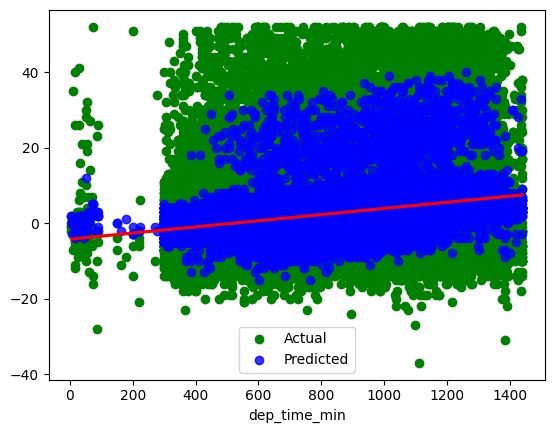

In [22]:
plt.scatter(x = X_val.dep_time_min, y = y_val, color = 'green', label = 'Actual')
sns.regplot(x = X_val.dep_time_min,y = y_prediction,ci=None,color ='blue',line_kws={"color": "red"}, label = 'Predicted')

plt.legend()
plt.show()

#### We can see that the model became a little bit too general and a polynomial regression might be a better fit. I will try 3rd-degree polynomial because 'dep_time_min' is the most important feature which is populated for each flight and 'dep_time_min' wise the data looks close to a cubic function.

## Model1.2: Polynomial LinearRegression

#### I have to use less features because of memory consumtion

In [23]:
less_features = ['dep_time_min','arrival_ARR_DELAY','arrival_LATE_AIRCRAFT_DELAY', 'dep_time_based_expected_delay']

X_train_poly = X_train[less_features]
X_val_poly = X_val[less_features]

In [24]:
poly = PolynomialFeatures(degree = 3)

X_train_poly_train = poly.fit_transform(X_train_poly)
X_val_poly_val = poly.transform(X_val_poly)

In [25]:
# # LinearRegression==============
pln = LinearRegression()
pln.fit(X_train_poly_train, y_train)
print('='*20)
print('LinearRegression')
print(f'accuracy of train set: {pln.score(X_train_poly_train, y_train)}')
print(f'accuracy of val set: {pln.score(X_val_poly_val, y_val)}')

y_prediction = pln.predict(X_val_poly_val).round(0).astype(int)
#print model metrics
df_pred = model_function.evaluate_prediction(y_prediction,y_val)

LinearRegression
accuracy of train set: 0.13666220004486496
accuracy of val set: 0.13413105808914183
model mean squared error: 131.46279209940653
model R2: -5.595924742853681
0 diff: 0.04838186201780415
1 diff: 0.14215504451038577
5 diff: 0.4885246661721068


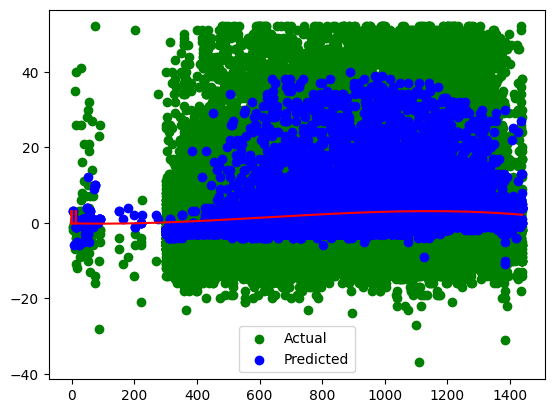

In [26]:
x_reg = np.arange(0,1440)
x_reg = pd.DataFrame(x_reg)
x_reg[['arrival_ARR_DELAY','arrival_LATE_AIRCRAFT_DELAY','dep_time_based_expected_delay']] =\
                        X_val_poly['arrival_ARR_DELAY'].mean(),\
                        X_val_poly['arrival_LATE_AIRCRAFT_DELAY'].mean(),\
                        X_val_poly['dep_time_based_expected_delay'].mean()


y_reg = pln.predict(poly.transform(x_reg))

plt.scatter(X_val_poly.dep_time_min, y_val, color = 'green', label = 'Actual')
plt.scatter(X_val_poly.dep_time_min, y_prediction, color = 'blue', label = 'Predicted')

plt.legend()
plt.plot(x_reg, y_reg, color = 'red')
plt.show()

#### The model looks better but a bit general still, lets separate the airlines.

## Model1.3: Separate Polynomial LinearRegression for each airlines

In [27]:
df_model_AA = df_model[df_model['AA'] == 1]

In [28]:
df_model_AA = model_function.get_origin_data(df_model_AA)

In [29]:
dummy_columns_list = ['airport']
df_model_AA = model_function.categorical_to_numerical_convert(df_model_AA,dummy_columns_list)

In [30]:
#selectiong train features(X_train) and traing targets(y_train)
train_feature = ['dep_time_min', 'ATL', 'AUS', 'BNA', 'BOS', 'BUR', 'BWI', 'CLE',
       'CLT', 'CMH', 'DCA', 'DEN', 'DFW', 'DTW', 'EWR', 'FLL', 'IAD', 'IAH',
       'IND', 'JAX', 'JFK', 'LAS', 'LAX', 'LGA', 'MCI', 'MCO', 'MIA', 'MKE',
       'MSP', 'MSY', 'OAK', 'OMA', 'ORD', 'PDX', 'PHL', 'PHX', 'PIT', 'RDU',
       'SAN', 'SAT', 'SEA', 'SFO', 'SJC', 'SLC', 'SMF', 'SNA', 'STL', 'TPA',
       'other_airport']

train_target = 'mean'

train_df_AA = df_model_AA.iloc[:,~df_model_AA.columns.isin([train_target])].astype('int16')
target_df_AA = df_model_AA[train_target].astype('int16')

In [31]:
#splitting the dataframes into train and val datasets
X_train_AA, X_val_AA, y_train_AA, y_val_AA = train_test_split(train_df_AA, target_df_AA, test_size=0.2, random_state=0)

In [32]:
poly = PolynomialFeatures(degree = 3)

X_train_AA_poly = poly.fit_transform(X_train_AA)
X_val_AA_poly = poly.transform(X_val_AA)

In [33]:
# # LinearRegression==============
pln = LinearRegression()
pln.fit(X_train_AA_poly, y_train_AA)
print('='*20)
print('LinearRegression')
print(f'accuracy of train set: {pln.score(X_train_AA_poly, y_train_AA)}')
print(f'accuracy of val set: {pln.score(X_val_AA_poly, y_val_AA)}')

y_prediction = pln.predict(X_val_AA_poly).round(0).astype(int)
#print model metrics
df_pred = model_function.evaluate_prediction(y_prediction,y_val_AA)

LinearRegression
accuracy of train set: 0.22922102261784882
accuracy of val set: 0.13968715548771682
model mean squared error: 61.47065868263473
model R2: -2.3412878748308072
0 diff: 0.06946107784431138
1 diff: 0.20838323353293414
5 diff: 0.6491017964071857


In [34]:
#using polynomial features is demanding therefore I have to use a vary small testset
testx = df_model[df_model['AA'] == 1][:15000][train_df_AA.columns]
testy = df_model[df_model['AA'] == 1][:15000]['departure_DEP_DELAY']
#testx = testx.loc[:, (testx != 0).any(axis=0)]

testx_AA_poly = poly.transform(testx)
prediction_y = pln.predict(testx_AA_poly).round(0).astype(int)
#print model metrics
df_pred = model_function.evaluate_prediction(prediction_y,testy)

model mean squared error: 161.35146666666665
model R2: -8.116684426160996
0 diff: 0.032466666666666665
1 diff: 0.10226666666666667
5 diff: 0.3938


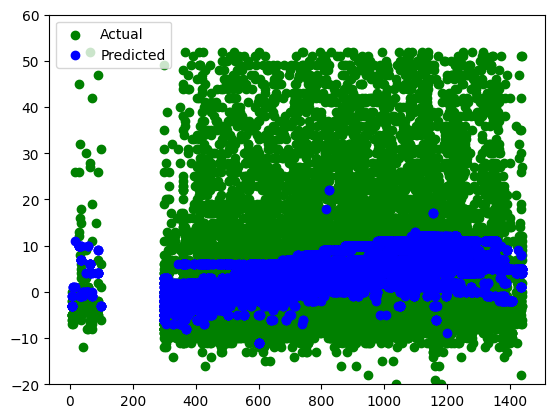

In [35]:
plt.scatter(testx.dep_time_min, testy, color = 'green', label = 'Actual')
plt.scatter(testx.dep_time_min, prediction_y, color = 'blue', label = 'Predicted')

plt.ylim([-20,60])
plt.legend()
plt.show()

# Model 2: Bucket DecisionTreeClassification

In [36]:
df_model_classification = df_model.copy()

In [ ]:
#bucketing based on arrival flight distance
delay_buckets = ['-60-30','-30-15','-15-12','-12-9','-9-6','-6-3','-3-0',
                 '0-3','3-6','6-9','9-12','12-15','15-30','30-60']

#delay bucket bin intervals
delay_bins = [-60,-30,-15,-12,-9,-6,-3,0,3,6,9,12,15,30,60]

#delay bucket value dict
delay_buckets_dic = {'-60-30': -30,
                     '-30-15': -15,
                     '-15-12': -13,
                     '-12-9': -10,
                     '-9-6': -7,
                     '-6-3': -4,
                     '-3-0': -1,
                     '0-3' : 1,
                     '3-6': 4,
                     '6-9': 7,
                     '9-12': 10,
                     '12-15': 13,
                     '15-30': 15,
                     '30-60':30}

df_model_classification['target_bin'] = pd.cut(df_model_classification['departure_DEP_DELAY'],
                                            bins=delay_bins,
                                            labels=delay_buckets)

#selectiong train features(X_train) and traing targets(y_train)
train_feature = ['dep_time_min', 'arrival_ARR_DELAY',
                   'arrival_LATE_AIRCRAFT_DELAY', 'dep_time_based_expected_delay',
                   'arrival_CARRIER_DELAY', 'arrival_NAS_DELAY', 'arrival_WEATHER_DELAY',
                   'origin_based_expected_delay', 'airline_based_expected_delay', 'AA',
                   'B6', 'DL', 'MQ', 'OO', 'UA', 'WN', 'YX', 'ATL', 'AUS', 'BNA', 'BOS',
                   'BUR', 'BWI', 'CLE', 'CLT', 'CMH', 'DAL', 'DCA', 'DEN', 'DFW', 'DTW',
                   'EWR', 'FLL', 'HOU', 'IAD', 'IAH', 'IND', 'JAX', 'JFK', 'LAS', 'LAX',
                   'LGA', 'MCI', 'MCO', 'MDW', 'MIA', 'MKE', 'MSP', 'MSY', 'OAK', 'OMA',
                   'ORD', 'PDX', 'PHL', 'PHX', 'PIT', 'RDU', 'SAN', 'SAT', 'SEA', 'SFO',
                   'SJC', 'SLC', 'SMF', 'SNA', 'STL', 'TPA', 'other_airport']

train_target = ['departure_DEP_DELAY','target_bin']

#separating X_full_train and y_full_train datasets
df_model_classification.reset_index(inplace = True, drop = True)
train_df = df_model_classification[train_feature].astype('int32')
target_df = df_model_classification[train_target]

#splitting the dataframes into train and val datasets
X_train, X_val, y_train, y_val = train_test_split(train_df, target_df, test_size=0.2, random_state=0)

In [ ]:
# # DecisionTreeClassifier==============
dtc = DecisionTreeClassifier(max_depth=11,random_state=42)
dtc.fit(X_train, y_train.target_bin)
print('='*20)
print('DecisionTreeClassifier')
print(f'accuracy of train set: {dtc.score(X_train, y_train.target_bin)}')
print(f'accuracy of val set: {dtc.score(X_val, y_val.target_bin)}')

y_prediction = dtc.predict(X_val)

In [1]:
y_val_t = y_val['departure_DEP_DELAY'].values
y_val_v = y_val['target_bin'].values
df_pred = pd.DataFrame({'pred': y_prediction, 
                        'actual': y_val_v , 'target': y_val_t}, columns=['pred', 'actual','target'])

df_pred['pred2'] = df_pred['pred'].replace(delay_buckets_dic).astype(int)
df_pred['actual2'] = df_pred['actual'].replace(delay_buckets_dic).astype(int)

#print model metrics
df_pred = model_function.evaluate_prediction(df_pred['pred2'].values,df_pred['target'].values)

NameError: name 'y_val' is not defined

Text(0.5, 0, 'Actual')

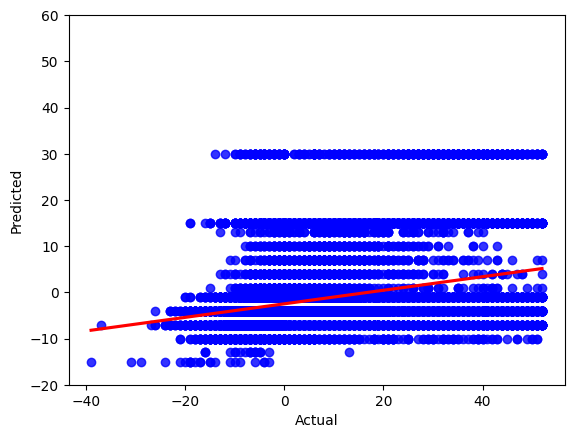

In [20]:
sns.regplot(x=df_pred.actual, 
            y=df_pred.pred, ci=None,color ='blue', line_kws={"color": "red"});

plt.ylim([-20,60])
plt.ylabel('Predicted')
plt.xlabel('Actual')

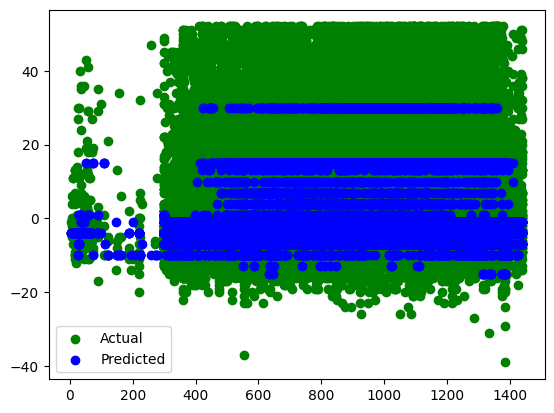

In [21]:
plt.scatter(X_val.dep_time_min, df_pred.actual, color = 'green', label = 'Actual')
plt.scatter(X_val.dep_time_min, df_pred.pred, color = 'blue', label = 'Predicted')

plt.legend()
plt.show()

# ------------------- Conclusion --------------

### The 1.3 Polynomial Regression looked promising however due to the reason that it needs 8 models to perform well and its memory consumption, I will choose the last DecisionTreeClassifier which performed quite well.

## Lets save the model so that not even a dying kernel can stop us

In [22]:
import pickle
output_file = 'hire_me_model.bin'

#save the model
with open(output_file, 'wb') as f_out:
    pickle.dump(dtc, f_out)

# ---------------------- Test the model ------------------
#### I am very sorry but for now you have to run the classes in the notebook before testing the model

In [7]:
import pickle
input_file = 'hire_me_model.bin'

#load the model
with open(input_file, 'rb') as f_in:
    final_model = pickle.load(f_in)

In [ ]:
#load test data
test_csv_list = ['2019_07','2019_08']
for csv in test_csv_list:
    
    df = pd.read_csv(f'DS_data_input/{csv}.csv')
    df.drop(['CANCELLATION_CODE','Unnamed: 22'], axis=1, inplace=True)
    
    try:
        df_test = pd.concat([df_test,df])
    except:
        df_test = df

In [12]:
#prepare the dataframe
carrier_list = ['WN','DL','AA','OO','UA','MQ','YX','B6']
data_preparation(df_test,carrier_list)

#add previous flights
dep = pd.read_parquet('DS_intermediate_data/flight_departure_data.parquet', engine='fastparquet')
arr = pd.read_csv('DS_intermediate_data/flight_arrival_data.csv')
data_engineering(dep, arr, kind = 'test')

Data Preparation is done


In [16]:
#read parquet
dep_plus_test = pd.read_parquet('DS_intermediate_data/flight_departure_plus_data_test.parquet', engine='fastparquet')
#create extra features
feature_engineering_test = feature_engineering(dep_plus_test,uscal)
dep_plus_test = feature_engineering_test.give_dataframe()

In [18]:
model_function = model_support_functions()

selected_features = ['departure_DEP_DELAY','dep_time_min','departure_OP_UNIQUE_CARRIER','departure_ORIGIN',
                     'arrival_ARR_DELAY','arrival_LATE_AIRCRAFT_DELAY','dep_time_based_expected_delay',
                     'arrival_CARRIER_DELAY','arrival_NAS_DELAY','arrival_WEATHER_DELAY','origin_based_expected_delay',
                     'airline_based_expected_delay']

#select only the top features to faster computation
df_model_test = dep_plus_test[selected_features]
# convert categorical features to binary columns
cat_columns = ['departure_OP_UNIQUE_CARRIER','departure_ORIGIN']
df_model_test = model_function.categorical_to_numerical_convert(df_model_test,cat_columns)

## If we want to try predicting huge delays

In [25]:
#delay bucket value dict
delay_buckets_dic = {'-60-30': -30,
                     '-30-15': -15,
                     '-15-12': -13,
                     '-12-9': -10,
                     '-9-6': -7,
                     '-6-3': -4,
                     '-3-0': -1,
                     '0-3' : 1,
                     '3-6': 4,
                     '6-9': 7,
                     '9-12': 10,
                     '12-15': 13,
                     '15-30': 15,
                     '30-60':30}


#selectiong train features(X_train) and traing targets(y_train)
train_feature = ['dep_time_min', 'arrival_ARR_DELAY',
                   'arrival_LATE_AIRCRAFT_DELAY', 'dep_time_based_expected_delay',
                   'arrival_CARRIER_DELAY', 'arrival_NAS_DELAY', 'arrival_WEATHER_DELAY',
                   'origin_based_expected_delay', 'airline_based_expected_delay', 'AA',
                   'B6', 'DL', 'MQ', 'OO', 'UA', 'WN', 'YX', 'ATL', 'AUS', 'BNA', 'BOS',
                   'BUR', 'BWI', 'CLE', 'CLT', 'CMH', 'DAL', 'DCA', 'DEN', 'DFW', 'DTW',
                   'EWR', 'FLL', 'HOU', 'IAD', 'IAH', 'IND', 'JAX', 'JFK', 'LAS', 'LAX',
                   'LGA', 'MCI', 'MCO', 'MDW', 'MIA', 'MKE', 'MSP', 'MSY', 'OAK', 'OMA',
                   'ORD', 'PDX', 'PHL', 'PHX', 'PIT', 'RDU', 'SAN', 'SAT', 'SEA', 'SFO',
                   'SJC', 'SLC', 'SMF', 'SNA', 'STL', 'TPA', 'other_airport']

In [69]:
#filling out missing columns
missing = list(set(train_feature) - set(list(df_model_test.columns)))
df_model_test[missing] = 0

In [70]:
#finalizing test dataset
X_test = df_model_test[train_feature]
y_test = df_model_test['departure_DEP_DELAY']

In [71]:
test_prediction = final_model.predict(X_test)
df_pred = pd.DataFrame({'pred': test_prediction, 'actual': y_test }, columns=['pred', 'actual'])
df_pred['pred2'] = df_pred['pred'].replace(delay_buckets_dic).astype(int)
#print model metrics
df_pred = model_function.evaluate_prediction(df_pred['pred2'].values,df_pred['actual'].values)

model mean squared error: 2953.907811040524
model R2: -56.05675316855738
0 diff: 0.08021860745678186
1 diff: 0.23677935293322547
5 diff: 0.6140144003324706


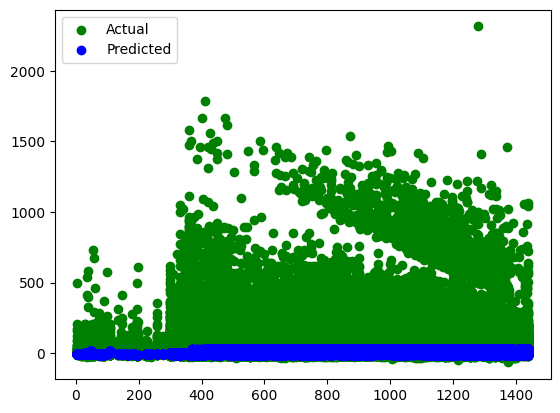

In [72]:
#visualizing the results
plt.scatter(X_test.dep_time_min, df_pred.actual, color = 'green', label = 'Actual')
plt.scatter(X_test.dep_time_min, df_pred.pred, color = 'blue', label = 'Predicted')

plt.legend()
plt.show()

## If we accept that we can't predict 60+min delays accurately yet

In [73]:
# filter out outlier delays as it would possible damage the model
df_model_test = model_function.IQR_outlier_treatment(df_model_test, 'departure_DEP_DELAY',20,80)
df_model_test = model_function.IQR_outlier_treatment(df_model_test, 'arrival_ARR_DELAY',5,95)

In [74]:
#delay bucket value dict
delay_buckets_dic = {'-60-30': -30,
                     '-30-15': -15,
                     '-15-12': -13,
                     '-12-9': -10,
                     '-9-6': -7,
                     '-6-3': -4,
                     '-3-0': -1,
                     '0-3' : 1,
                     '3-6': 4,
                     '6-9': 7,
                     '9-12': 10,
                     '12-15': 13,
                     '15-30': 15,
                     '30-60':30}


#selectiong train features(X_train) and traing targets(y_train)
train_feature = ['dep_time_min', 'arrival_ARR_DELAY',
                   'arrival_LATE_AIRCRAFT_DELAY', 'dep_time_based_expected_delay',
                   'arrival_CARRIER_DELAY', 'arrival_NAS_DELAY', 'arrival_WEATHER_DELAY',
                   'origin_based_expected_delay', 'airline_based_expected_delay', 'AA',
                   'B6', 'DL', 'MQ', 'OO', 'UA', 'WN', 'YX', 'ATL', 'AUS', 'BNA', 'BOS',
                   'BUR', 'BWI', 'CLE', 'CLT', 'CMH', 'DAL', 'DCA', 'DEN', 'DFW', 'DTW',
                   'EWR', 'FLL', 'HOU', 'IAD', 'IAH', 'IND', 'JAX', 'JFK', 'LAS', 'LAX',
                   'LGA', 'MCI', 'MCO', 'MDW', 'MIA', 'MKE', 'MSP', 'MSY', 'OAK', 'OMA',
                   'ORD', 'PDX', 'PHL', 'PHX', 'PIT', 'RDU', 'SAN', 'SAT', 'SEA', 'SFO',
                   'SJC', 'SLC', 'SMF', 'SNA', 'STL', 'TPA', 'other_airport']

In [75]:
#filling out missing columns
missing = list(set(train_feature) - set(list(df_model_test.columns)))
df_model_test[missing] = 0

In [76]:
#finalizing test dataset
X_test = df_model_test[train_feature]
y_test = df_model_test['departure_DEP_DELAY']

In [77]:
test_prediction = final_model.predict(X_test)
df_pred = pd.DataFrame({'pred': test_prediction, 'actual': y_test }, columns=['pred', 'actual'])
df_pred['pred2'] = df_pred['pred'].replace(delay_buckets_dic).astype(int)
#print model metrics
df_pred = model_function.evaluate_prediction(df_pred['pred2'].values,df_pred['actual'].values)

model mean squared error: 132.63148588892344
model R2: -3.049306181152563
0 diff: 0.08943100425067727
1 diff: 0.26396119848363964
5 diff: 0.6840547764901035


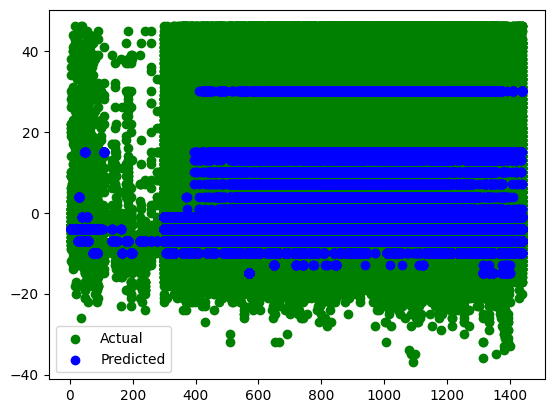

In [78]:
#visualizing the results
plt.scatter(X_test.dep_time_min, df_pred.actual, color = 'green', label = 'Actual')
plt.scatter(X_test.dep_time_min, df_pred.pred, color = 'blue', label = 'Predicted')

plt.legend()
plt.show()

### Model performed as expected, not too good not too bad. I have a ton of ideas on how to improve it and I am confident that by running the code on cluster/using spark/adding more features/adding weather and airport data we can boost the model significantly.

# Last word: Thank you for the time to evaluate this notebook and I am looking forward to explain my thought process and future ideas. See you soon!